# Arrehnius and Modified Arrhenius

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.kinetic_constants import Arrhenius

This tutorial demonstrates the computation of kinetic rate constants for a simple Arrhenius reaction across a specified temperature range. The implementation focuses solely on the forward reaction rate constant, as determined by user-provided parameters. Note that this code does not incorporate chemical equilibrium calculations, thus considering only unidirectional reaction kinetics.
- Equation
    > $k_f(T) = A \: T^n \: exp\left(\frac{Eact}{RT}\right)$
- CHEMKIN representation
    >```
    >H2 + O = H + OH    +5.080E+04 +2.670E+00 +6.292E+03
    >```
- Internal representation of the rate constant can be done in different ways:
  1. As a python dictionary, passing directly the dictionary to the Arrhenius object
     
    >```python
    >rate_constant = {
    >    "name": "H2+O=H+OH",
    >    "type": "arrhenius",
    >    "rate-constant": {
    >        "coefficients": [5.080e+04, 2.670E+00, 6.292e+03]
    >    }
    >}
    >rate_constant = Arrhenius(rate_constant_dictionary)
    >```

  2. As a python array (keep in mind that in this case the name is optional and can be omitted), passing directly the list of parameters to the Arrhenius object
     
    >```python
    >rate_constant = Arrhenius(name="H2+O=H+OH", params=[5.080e+04, 2.670E+00, 6.292e+03])
    >```

In [2]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
rate_constant_dictionary = {
    "name": "H2+O=H+OH",
    "type": "arrhenius",
    "rate-constant": {
        "coefficients": [5.080e+04, 2.670E+00, 6.292e+03]
    }
}
rate_constant = Arrhenius(rate_constant_dictionary)

# --------------------------------------------------------
# Direct parameters initialization
# --------------------------------------------------------
rate_constant = Arrhenius(name="H2+O=H+OH", params=[5.080e+04, 2.670E+00, 6.292e+03])

## Kinetic constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the Arrhenius object, including the calculation of the kinetic constant across different temperature ranges. Keep in mind that the standard or modified arrhenius expression express the kinetic constant only as a temperature dependent function.

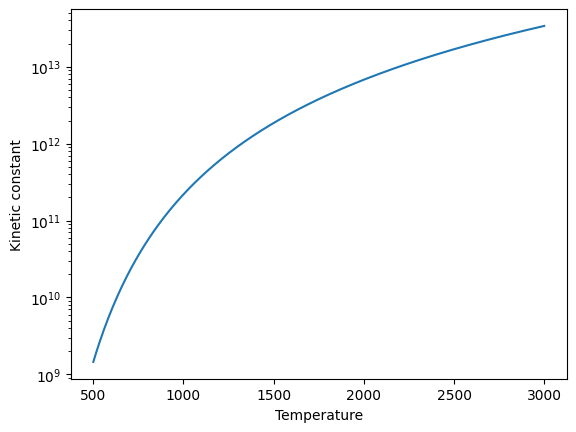

In [3]:
# --------------------------------------------------------
# Rate constant initialization
# --------------------------------------------------------
rate_constant = Arrhenius(params=[5.080e+04, 2.670E+00, 6.292e+03])  # Note: name is optional

# --------------------------------------------------------
# Compute the kinetic constant
# --------------------------------------------------------
T_range = jnp.linspace(500, 3000, 300)
kinetic_constant = rate_constant.kinetic_constant(T_range)

# Let's visualize it
plt.semilogy(T_range, kinetic_constant)
plt.xlabel("Temperature")
plt.ylabel("Kinetic constant")
plt.show()

When analyzing reaction kinetics, you often have experimental data of reaction rate constants measured at different temperatures rather than pre-determined Arrhenius parameters. The `Arrhenius.from_data` method provides a convenient way to fit your experimental data to the Arrhenius equation directly.

The Arrhenius equation can be expressed in different forms:

- Two-parameter form: $k_f(T) = A \: exp\left(\frac{Eact}{RT}\right)$
- Three-parameter form: $k_f(T) = A \: T^n \: exp\left(\frac{Eact}{RT}\right)$

The `from_data` classmethod performs a least-squares regression on the logarithmic form of the equation:

- $ln⁡(k)=ln⁡(A)+n \: ln⁡(T)−\frac{Ea}{R} \: \frac{1}{T}$

This allows for fitting: Pre-exponential factor (A), Temperature exponent (n) - optional, set to 0 for two-parameter model, Activation energy (Ea).


True Arrhenius parameters:
A = 2.4000e+12 cm³/(mol·s)
n = 0.2700
Ea = 38300.0 cal/mol

3-parameter model fit:
A = 1.4824e+13 cm³/(mol·s)
n = 0.0494
Ea = 38847.1 cal/mol

2-parameter model fit:
A = 2.2171e+13 cm³/(mol·s)
n = 0.0000
Ea = 38969.8 cal/mol

Fit quality:
Mean relative error (3-parameter): 2.91%
Mean relative error (2-parameter): 2.94%


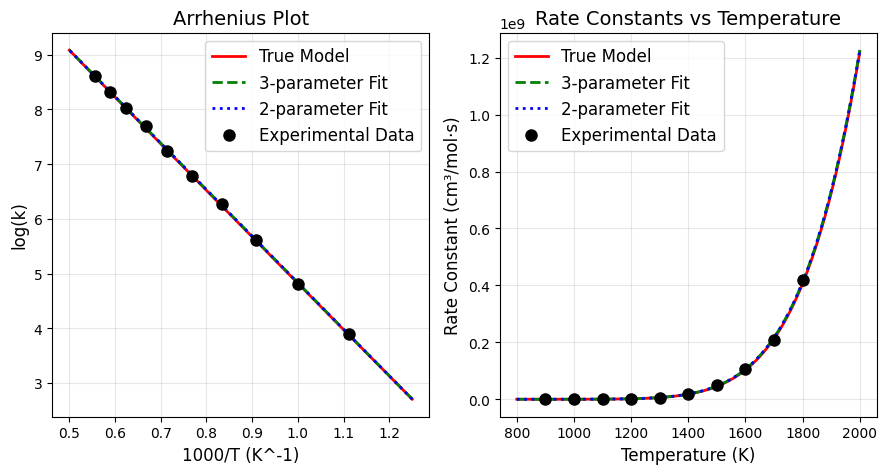

In [9]:
# --------------------------------------------------------
# Let's create synthetic data for demonstration
# --------------------------------------------------------
A_true = 2.4e12  # cm³/(mol·s)
n_true = 0.27    # dimensionless
Ea_true = 38300  # cal/mol
true_rate_constant = Arrhenius(params=[A_true, n_true, Ea_true])
def simulate_rxn_data():
    temps = jnp.array([900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800])
    rates = true_rate_constant.kinetic_constant(temps)
    
    # Add experimental noise (5% random error)
    np.random.seed(42)
    noisy_rates = rates * (1 + 0.05 * np.random.randn(len(temps)))
    return temps, noisy_rates

# --------------------------------------------------------
# Generate experimental data with 5% noise
# --------------------------------------------------------
temps, rates = simulate_rxn_data()

# --------------------------------------------------------
# Fit the data using Arrhenius.from_data with both 2 and 3 parameters
# --------------------------------------------------------
rxn_3param = Arrhenius.from_data(
    rates=rates,
    temps=temps,
    three_params=True
)
    
rxn_2param = Arrhenius.from_data(
    rates=rates,
    temps=temps,
    three_params=False
)

# --------------------------------------------------------    
# Extract parameters from both fits
# --------------------------------------------------------
A3, n3, Ea3 = rxn_3param.get_parameters()
A2, n2, Ea2 = rxn_2param.get_parameters()

# --------------------------------------------------------    
# Print results
# --------------------------------------------------------
print("\nTrue Arrhenius parameters:")
print(f"A = {A_true:.4e} cm³/(mol·s)")
print(f"n = {n_true:.4f}")
print(f"Ea = {Ea_true:.1f} cal/mol")
    
print("\n3-parameter model fit:")
print(f"A = {A3:.4e} cm³/(mol·s)")
print(f"n = {n3:.4f}")
print(f"Ea = {Ea3:.1f} cal/mol")
    
print("\n2-parameter model fit:")
print(f"A = {A2:.4e} cm³/(mol·s)")
print(f"n = {n2:.4f}")  # Should be close to 0
print(f"Ea = {Ea2:.1f} cal/mol")
    
# Create plot to visualize fits
T_range = jnp.linspace(800, 2000, 100)
    
true_k = true_rate_constant.kinetic_constant(T_range)
fit3_k = rxn_3param.kinetic_constant(T_range)
fit2_k = rxn_2param.kinetic_constant(T_range)
    
plt.figure(figsize=(9, 5))
    
# Arrhenius plot (log(k) vs 1/T)
plt.subplot(1, 2, 1)
plt.plot(1000/T_range, jnp.log10(true_k), 'r-', linewidth=2, label='True Model')
plt.plot(1000/T_range, jnp.log10(fit3_k), 'g--', linewidth=2, label='3-parameter Fit')
plt.plot(1000/T_range, jnp.log10(fit2_k), 'b:', linewidth=2, label='2-parameter Fit')
plt.plot(1000/temps, jnp.log10(rates), 'ko', markersize=8, label='Experimental Data')
plt.xlabel('1000/T (K^-1)', fontsize=12)
plt.ylabel('log(k)', fontsize=12)
plt.title('Arrhenius Plot', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
    
# Rate constants vs T
plt.subplot(1, 2, 2)
plt.plot(T_range, true_k, 'r-', linewidth=2, label='True Model')
plt.plot(T_range, fit3_k, 'g--', linewidth=2, label='3-parameter Fit')
plt.plot(T_range, fit2_k, 'b:', linewidth=2, label='2-parameter Fit')
plt.plot(temps, rates, 'ko', markersize=8, label='Experimental Data')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Rate Constant (cm³/mol·s)', fontsize=12)
plt.title('Rate Constants vs Temperature', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
    
plt.tight_layout()

    
# Calculate mean relative error to quantify fit quality
def mean_rel_error(y_true, y_pred):
    return jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100
    
error_3param = mean_rel_error(rates, rxn_3param.kinetic_constant(temps))
error_2param = mean_rel_error(rates, rxn_2param.kinetic_constant(temps))
    
print("\nFit quality:")
print(f"Mean relative error (3-parameter): {error_3param:.2f}%")
print(f"Mean relative error (2-parameter): {error_2param:.2f}%")